# Data Download from ESA CCI lake dataset

This script downloads (without the need of user login data) for a selected lake mask the data from the ESA CCI large lake dataset selected variables.

The DOI to the dataset: https://dx.doi.org/10.5285/7fc9df8070d34cacab8092e45ef276f1

In this case, this are the following variables that are of interest:
- 'lake_surface_water_temperature'
- 'lswt_uncertainty'
- 'lswt_quality_level',
- 'lake_ice_cover_flag',
- 'lake_ice_cover_class'

The ESA CCI lake dataset contains more than 2000 lakes globally, but only some for Greenland (14), and only 6 of them are ice-marginal lakes (for comparsion I used the Greenland ice-marginal lake dataset 2025 from How et al. 2025).
The mapping between ID's from the GrIML by How et al. 2025 (https://doi.org/10.5194/essd-17-6331-2025) and the ESA CCI global lake dataset is the following:

| lake_id / GrIML (How et al. 2025) | ESA CCI ID (Carrea et al.) |
|-----------------:|-------:|
| 12               |        |
| 1                | 300001720 |
| 2                |        |
| 7                | 300001744 |
| 3                | 300000182 |
| 9                | 300000185 |
| 6                | 300003969 |
| 8                |        |
| 4                |        |
| 16               | 300002892 |


This code for downloading is based on the tutorial jupyter notebooks found on the CCI lakes github repository: https://github.com/cci-lakes/lakes_cci_tools, however, it has been deleted during the time of the internship (showing that athere is high activity), and this is the link to the deleted file (from the change log): https://github.com/cci-lakes/lakes_cci_tools/compare/875e8a490951057c97594d67474c16417c01b025...7665fd20606fe9d752ee67af39d1691a0f5c2f0c


The following implements the download of the lake Kangaarsuup Tasersua, lake_id 6, and lake in id in the CCI lake dataset 300003969 for all years. The mask file (excel) is needed for this. The source of the mask is this publication: https://rmets.onlinelibrary.wiley.com/doi/10.1002/gdj3.32




____________________________________________________________________________________________


# Description 

This script allows to generate a set of figures relating to a variable for a lakes in lakes_cci version 2.1.0 based in its id.

It is adapted to be executed via Binder (https://mybinder.org/)


INPUT:
    <ul>
    <li>The identifier of the lake. The id of the lake is indicated 
      in the csv file containing lake metadata. This file is available 
      at the project website:
      https://admin.climate.esa.int/documents/2607/lakescci_v2.1.0_metadata.csv </li>
    <li>Name of the variable in the netCDF files</li>
    <li>Land mask: the netCDF file containing the mask of the lakes in CCI datase (no changes in the landmask between v2.0.1 and v2.1) is available at: https://dap.ceda.ac.uk/neodc/esacci/lakes/data/lake_products/L3S/v2.0.1/ESA_CCI_static_lake_mask_v2.0.1.nc</li>
    <li>First/last dates</li>
    <li>Version of the dataset to be download (default value 2.1.0).</li>
    </ul>
    
 The complete dataset is available at CEDA : https://catalogue.ceda.ac.uk/uuid/7fc9df8070d34cacab8092e45ef276f1/

 Reference: Carrea, L.; Crétaux, J.-F.; Liu, X.; Wu, Y.; Bergé-Nguyen,
 M.; Calmettes, B.; Duguay, C.; Jiang, D.; Merchant, C.J.; Mueller, D.;
 Selmes, N.; Simis, S.; Spyrakos, E.; Stelzer, K.; Warren, M.; Yesou,
 H.; Zhang, D. (2022): ESA Lakes Climate Change Initiative (Lakes_cci):
 Lake products, Version 2.1.0. NERC EDS Centre for Environmental Data
 Analysis, date of citation.
 https://dx.doi.org/10.5285/7fc9df8070d34cacab8092e45ef276f1
 
    
 WARNING: This script is a beta version. All controls on the input parameters
 are not (yet) available. If you find a bug, have a question or a
 suggestion, don't hesitate to contact us, it will be much appreciated :
 cci_lakes.contact@groupcls.com



# key variables

Lakes_cci dataset is a merged product containing multiple variables from different thematic ECVs. The key variables are as follow:

<b>Lake Water Level (LWL):</b>
<ul><li>water_surface_height_above_reference_datum</li></ul>

<b>Lake Water Extent (LWE):</b>
<ul><li>lake_surface_water_extent</li></ul>

<b>Lake Ice Cover (LIC):</b>
<ul><li>lake_ice_cover_class</li></ul>


<b>Lake Surface Water Temperature (LSWT):</b>
<ul><li>lake_surface_water_temperature</li></ul>


<b>Lake Water Leaving Reflectance (LWLR):</b>
<ul><li>chla_mean</li>
<li>turbidity_mean</li>
<li>Rwxxx with xxx: 400, 412, 443, 469, 490, 510, 531, 547, 560, 620, 645, 665, 674, 681, 709, 754, 779, 859, 885, 900, 1020</li></ul>


In [13]:
import numpy as np
import netCDF4 as nc
import pandas as pd
import xarray as xr
import datetime
import matplotlib.pyplot as plt
import datetime
from tqdm.notebook import tqdm
import time

In [14]:
# list of variables in the netCDF files
lakes_cci_variables = ['Rw1020', 'Rw1020_uncertainty_relative','Rw1020_uncertainty_relative_unbiased',
                       'Rw400','Rw400_uncertainty_relative','Rw400_uncertainty_relative_unbiased',
                       'Rw412','Rw412_uncertainty_relative','Rw412_uncertainty_relative_unbiased',
                       'Rw443','Rw443_uncertainty_relative','Rw443_uncertainty_relative_unbiased',
                       'Rw469','Rw469_uncertainty_relative','Rw469_uncertainty_relative_unbiased',
                       'Rw490','Rw490_uncertainty_relative','Rw490_uncertainty_relative_unbiased',
                       'Rw510','Rw510_uncertainty_relative','Rw510_uncertainty_relative_unbiased',
                       'Rw547','Rw547_uncertainty_relative','Rw547_uncertainty_relative_unbiased',
                       'Rw560','Rw560_uncertainty_relative','Rw560_uncertainty_relative_unbiased',
                       'Rw620','Rw620_uncertainty_relative','Rw620_uncertainty_relative_unbiased',
                       'Rw531','Rw531_uncertainty_relative','Rw531_uncertainty_relative_unbiased',
                       'Rw645','Rw645_uncertainty_relative','Rw645_uncertainty_relative_unbiased',
                       'Rw665','Rw665_uncertainty_relative','Rw665_uncertainty_relative_unbiased',
                       'Rw674','Rw674_uncertainty_relative','Rw674_uncertainty_relative_unbiased',
                       'Rw681','Rw681_uncertainty_relative','Rw681_uncertainty_relative_unbiased',
                       'Rw709','Rw709_uncertainty_relative','Rw709_uncertainty_relative_unbiased',
                       'Rw754','Rw754_uncertainty_relative','Rw754_uncertainty_relative_unbiased',
                       'Rw779','Rw779_uncertainty_relative','Rw779_uncertainty_relative_unbiased',
                       'Rw859','Rw859_uncertainty_relative','Rw859_uncertainty_relative_unbiased',
                       'Rw885','Rw885_uncertainty_relative','Rw885_uncertainty_relative_unbiased',
                       'Rw900','Rw900_uncertainty_relative','Rw900_uncertainty_relative_unbiased',  
                       'chla_mean','chla_uncertainty','turbidity_mean','turbidity_uncertainty',
                       'lake_ice_cover_class','lake_ice_cover_flag','lake_ice_cover_uncertainty',
                       'lake_surface_water_temperature','lswt_uncertainty','lswt_quality_level',
                       'water_surface_height_above_reference_datum','lwl_uncertainty','lwl_quality_flag',
                       'lake_surface_water_extent','lwe_uncertainty','lwe_quality_flag',
                       'time', 'lat', 'lon']

In [ ]:
###########################################################################################
# input parameters
###########################################################################################   

# lakes mask file 
maskfile = 'ESA_CCI_static_lake_mask_v2.1.nc'

# Id for lake id 9 in GrIML by How et al. 2025
lake_id = 300003969

# all three lake surface water temperature related vars
#varname = 'lake_surface_water_temperature' 
#varname = 'lswt_uncertainty'
#varname = 'lswt_quality_level'
#varname = 'lake_ice_cover_flag'
varname = 'lake_ice_cover_class'


# defining the period of time in string format: YYYY-MM-DD
# dates values must be between 1992-09-26 and 2020-12-31

mindate = '2021-01-01'
maxdate = '2021-12-31'

In [22]:
# test if dates are in the temporal coverage

mindate = datetime.datetime.strptime(mindate, '%Y-%m-%d')
maxdate = datetime.datetime.strptime(maxdate, '%Y-%m-%d')
mindate = max([mindate, datetime.datetime(1992,9,26)])
maxdate = min([maxdate, datetime.datetime(2022,12,31)])


In [23]:
# test if varname in list of variables
if not varname in lakes_cci_variables:
    print (f'the varname "{varname}" does not exist in lakes_cci dataset' )

In [24]:
##################################################################################################
# create mask based on lake_id, source: https://rmets.onlinelibrary.wiley.com/doi/10.1002/gdj3.32
##################################################################################################
mask_nc = nc.Dataset(maskfile)

minx = []
maxx = []
miny = []
maxy = []

nc_var = mask_nc.variables["CCI_lakeid"]
shape =  nc_var.shape

step = int(np.ceil(shape[0] / 10))
steps = list(range(0, shape[0] + step, step))

i = steps[0]
for j in steps[1:]:
    mask = nc_var[i:j, :]
    mask_ind = np.where(mask == lake_id)

    if mask_ind[0].size > 0 or mask_ind[1].size > 0:
        minx.append(np.min(mask_ind[1][:]) - 1)
        maxx.append(np.max(mask_ind[1][:]) + 1)
        miny.append(np.min(mask_ind[0][:]) - 1 + i)
        maxy.append(np.max(mask_ind[0][:]) + 1 + i )
    del mask
    i = j

minx = np.min(minx)
maxx = np.max(maxx)
miny = np.min(miny)
maxy = np.max(maxy)

mask_lake =nc_var[miny : maxy + 1, minx : maxx + 1]
mask_lake[mask_lake != lake_id] = 0
mask_lake[mask_lake == lake_id] = 1


lon = mask_nc.variables['lon'][minx:maxx + 1]
lat = mask_nc.variables['lat'][miny:maxy + 1]



mask_nc.close()

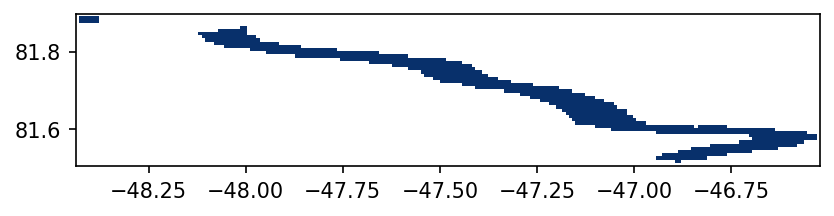

lon min:-48.4375
lon max:-46.52083206176758


In [25]:

###################################################################
# Plot lake mask
###################################################################

plt.imshow(np.flipud(mask_lake), extent=[lon[0], lon[-1], lat[0], lat[-1]], cmap = 'Blues_r')
ax = plt.gca()
ax.set_aspect('equal', adjustable='box')
plt.show()

print(f"lon min:{lon[0]}")
print(f"lon max:{lon[-1]}")

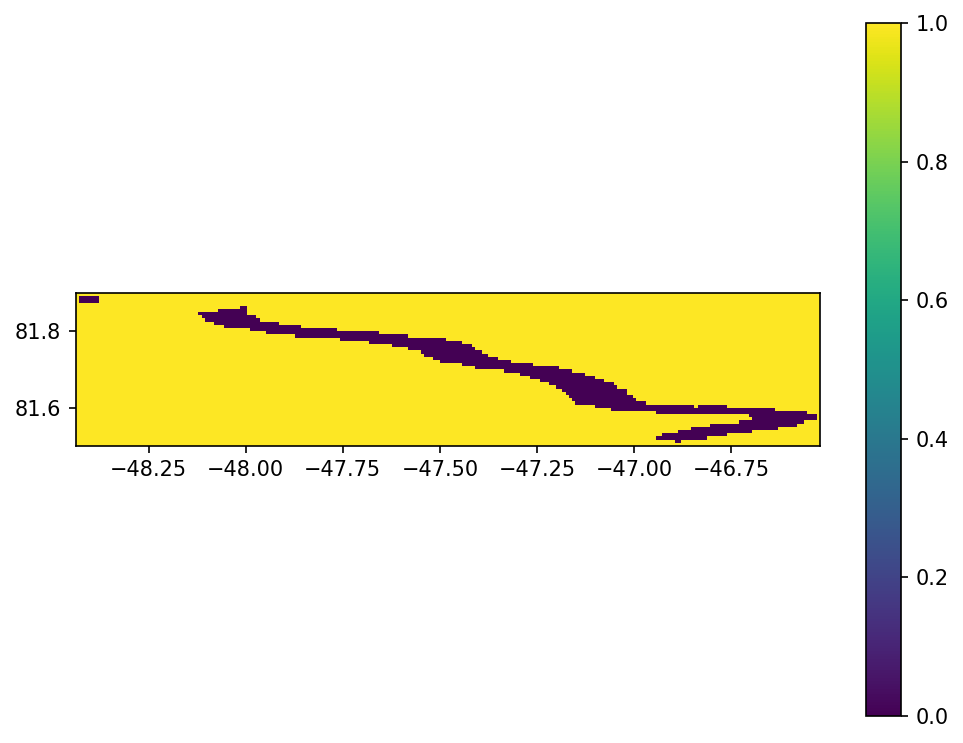

[[ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 [ True  True  True ...  True  True  True]
 ...
 [ True False False ...  True  True  True]
 [ True False False ...  True  True  True]
 [ True  True  True ...  True  True  True]]


<xarray.DataArray 'lake_mask' (lat: 48, lon: 231)> Size: 89kB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan,  1.,  1., ..., nan, nan, nan],
       [nan,  1.,  1., ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]], shape=(48, 231))
Coordinates:
  * lat      (lat) float32 192B 81.5 81.51 81.52 81.53 ... 81.88 81.89 81.9
  * lon      (lon) float32 924B -48.44 -48.43 -48.42 ... -46.54 -46.53 -46.52

In [26]:
# save the lon/lat to the lake_polygons folder (they are not saved anywhere else!)
np.savetxt("../lake_polygons/latidute_coords_lake_6.txt", lat)
np.savetxt("../lake_polygons/longitude_coords_lake_6.txt", lon)

mask_plot = np.array(mask_lake.mask)


import matplotlib.pyplot as plt

mask_plot = np.array(mask_lake.mask)

plt.figure(figsize=(8, 6))
plt.imshow(np.flipud(mask_plot), extent=[lon[0], lon[-1], lat[0], lat[-1]])
plt.colorbar()
plt.show()

### the lake in the plot is upside down
print(mask_plot)

### make the lon lat values:
mask_with_coords = xr.DataArray(
    mask_lake,
    coords={
        "lat": lat,
        "lon": lon
    },
    dims=["lat", "lon"],
    name="lake_mask"
)

# then write it to disk:
mask_with_coords.to_netcdf(f"lake_6_mask_with_buffer_and_coords.nc") # this works, has been double checked in QGIS, EPSG is 4326

mask_with_coords

# Download: First for one year and one variable
This can take longtime depending on the selected date range and area of the lake. 

In [9]:
# data storage
data = []
version = 2.1  # define version of the dataset

# total number of days
days_total = (maxdate - mindate).days + 1
start_time = time.perf_counter() # start time

# start loop
for i, data_date in enumerate(
    np.arange(mindate.toordinal(), maxdate.toordinal() + 1)):
    current_date = datetime.datetime.fromordinal(data_date)
    date_str = current_date.strftime("%Y%m%d")

    path = (f'https://data.cci.ceda.ac.uk/thredds/dodsC/'
        f'esacci/lakes/data/lake_products/L3S/v{version}/merged_product/'
        f'{current_date.year}/{current_date.month:02}/'
        f'ESACCI-LAKES-L3S-LK_PRODUCTS-MERGED-{date_str}-fv{version}.0.nc?{varname}')

    daily_data = xr.open_dataset(path)
    daily_data = daily_data.isel({"lat": slice(miny, maxy),"lon": slice(minx, maxx)})

    data.append(daily_data)

    # progress 
    percent = (i + 1) / days_total * 100
    print(f"\rProcessing: {percent:.1f}% ({i + 1}/{days_total})",end="",flush=True)

# all datasets together
ds_data = xr.concat(data, dim="time")

# end time
elapsed_time = time.perf_counter() - start_time
hours, remainder = divmod(elapsed_time, 3600)
minutes, seconds = divmod(remainder, 60)

print(f"\nIt took {hours}h, {minutes}min and {seconds}sec.") # roughly one day = 1sec

Processing: 4.7% (17/365)

KeyboardInterrupt: 

In [ ]:
# save data to folder:
ds_data.to_netcdf("processed_data/lake_ice_cover_class_2018.nc")



# Loop for all varnames and years for one lake

In [ ]:
import xarray as xr
import numpy as np
import datetime
import time
import os

# ============================================================
# SETTINGS
# ============================================================

# lake id
lake_id = 300003969

# Years to process
start_year = 2016
end_year = 2022

# Valid ESA CCI Lakes time range
valid_start = datetime.datetime(2016, 1, 1)
valid_end = datetime.datetime(2022, 12, 31)

# Variables to download
varnames_list = [
    'lake_surface_water_temperature',
    'lswt_uncertainty',
    'lswt_quality_level',
    'lake_ice_cover_flag',
    'lake_ice_cover_class'
]

# Dataset version
version = 2.1

# Spatial subset
# Make sure these are defined before running:
# minx, maxx, miny, maxy

# Base output folder
base_output_folder = "processed_data"

# ============================================================
# OVERALL TIMER
# ============================================================

overall_start = time.perf_counter()

# ============================================================
# LOOP OVER YEARS
# ============================================================

for year in range(start_year, end_year + 1):

    print("\n")
    print("#" * 70)
    print(f"PROCESSING YEAR: {year}")
    print("#" * 70)

    # --------------------------------------------------------
    # Define date range for this year
    # --------------------------------------------------------

    mindate = datetime.datetime(year, 1, 1)
    maxdate = datetime.datetime(year, 12, 31)

    # Restrict to valid ESA CCI time range
    mindate = max(mindate, valid_start)
    maxdate = min(maxdate, valid_end)

    # Skip years outside the valid range
    if mindate > maxdate:
        print(f"Skipping {year}: outside valid date range.")
        continue

    days_total = (maxdate - mindate).days + 1

    print(
        f"Date range: {mindate.strftime('%Y-%m-%d')} "
        f"to {maxdate.strftime('%Y-%m-%d')}"
    )
    print(f"Total days: {days_total}")

    # --------------------------------------------------------
    # Create year-specific output folder
    # --------------------------------------------------------

    output_folder = os.path.join(
        base_output_folder,
        str(year)
    )

    os.makedirs(output_folder, exist_ok=True)

    # --------------------------------------------------------
    # LOOP OVER VARIABLES
    # --------------------------------------------------------

    for varname in varnames_list:

        print("\n" + "=" * 60)
        print(f"Year: {year}")
        print(f"Downloading variable: {varname}")
        print("=" * 60)

        start_time = time.perf_counter()

        # Storage for daily datasets
        data = []

        # ----------------------------------------------------
        # LOOP OVER DAYS
        # ----------------------------------------------------

        for i, data_date in enumerate(
            np.arange(
                mindate.toordinal(),
                maxdate.toordinal() + 1
            )
        ):

            current_date = datetime.datetime.fromordinal(
                data_date
            )

            date_str = current_date.strftime("%Y%m%d")

            # ------------------------------------------------
            # Construct OPeNDAP URL
            # ------------------------------------------------

            path = (
                f'https://data.cci.ceda.ac.uk/thredds/dodsC/'
                f'esacci/lakes/data/lake_products/L3S/v{version}/'
                f'merged_product/'
                f'{current_date.year}/'
                f'{current_date.month:02}/'
                f'ESACCI-LAKES-L3S-LK_PRODUCTS-MERGED-'
                f'{date_str}-fv{version}.0.nc?{varname}'
            )

            try:
                # --------------------------------------------
                # Open daily dataset
                # --------------------------------------------

                daily_data = xr.open_dataset(path)

                # --------------------------------------------
                # Spatial subset
                # --------------------------------------------

                daily_data = daily_data.isel({
                    "lat": slice(miny, maxy),
                    "lon": slice(minx, maxx)
                })

                data.append(daily_data)

            except Exception as e:

                print(
                    f"\nWARNING: Could not download "
                    f"{date_str} for {varname}"
                )
                print(f"Error: {e}")

            # --------------------------------------------
            # Progress
            # --------------------------------------------

            percent = (i + 1) / days_total * 100

            print(
                f"\r{varname} {year}: "
                f"{percent:.1f}% "
                f"({i + 1}/{days_total})",
                end="",
                flush=True
            )

        # ----------------------------------------------------
        # Check whether anything was downloaded
        # ----------------------------------------------------

        if len(data) == 0:

            print(
                f"\nNo data downloaded for "
                f"{varname} in {year}. Skipping."
            )

            continue

        # ----------------------------------------------------
        # Concatenate all days
        # ----------------------------------------------------

        print("\nConcatenating daily datasets...")

        ds_data = xr.concat(
            data,
            dim="time"
        )

        # ----------------------------------------------------
        # Output filename
        # ----------------------------------------------------

        output_file = os.path.join(
            output_folder,
            f"lake_{lake_id}_{varname}_{year}.nc"
        )

        # ----------------------------------------------------
        # Save to NetCDF
        # ----------------------------------------------------

        print(f"Saving to: {output_file}")

        ds_data.to_netcdf(output_file)

        # ----------------------------------------------------
        # Close datasets
        # ----------------------------------------------------

        ds_data.close()

        for ds in data:
            ds.close()

        # ----------------------------------------------------
        # Timing
        # ----------------------------------------------------

        elapsed_time = time.perf_counter() - start_time

        hours, remainder = divmod(
            elapsed_time,
            3600
        )

        minutes, seconds = divmod(
            remainder,
            60
        )

        print(
            f"Finished {varname} for {year}"
        )

        print(
            f"Time: "
            f"{int(hours)}h, "
            f"{int(minutes)}min, "
            f"{seconds:.1f}sec"
        )

    print(f"\nCompleted year {year}.")

# ============================================================
# OVERALL TIMING
# ============================================================

overall_elapsed = time.perf_counter() - overall_start

hours, remainder = divmod(
    overall_elapsed,
    3600
)

minutes, seconds = divmod(
    remainder,
    60
)

print("\n" + "#" * 70)
print(
    f"ALL YEARS FINISHED"
)
print(
    f"Total time: "
    f"{int(hours)}h, "
    f"{int(minutes)}min, "
    f"{seconds:.1f}sec"
)
print("#" * 70)



######################################################################
PROCESSING YEAR: 2016
######################################################################
Date range: 2016-01-01 to 2016-12-31
Total days: 366

Year: 2016
lake_surface_water_temperature 2016: 100.0% (366/366)
Concatenating daily datasets...
Saving to: processed_data\2016\lake_1_lake_surface_water_temperature_2016.nc
Finished lake_surface_water_temperature for 2016
Time: 0h, 10min, 14.5sec

Year: 2016
lswt_uncertainty 2016: 100.0% (366/366)
Concatenating daily datasets...
Saving to: processed_data\2016\lake_1_lswt_uncertainty_2016.nc
Finished lswt_uncertainty for 2016
Time: 0h, 10min, 1.2sec

Year: 2016
lswt_quality_level 2016: 100.0% (366/366)
Concatenating daily datasets...
Saving to: processed_data\2016\lake_1_lswt_quality_level_2016.nc
Finished lswt_quality_level for 2016
Time: 0h, 9min, 51.7sec

Year: 2016
lake_ice_cover_flag 2016: 100.0% (366/366)
Concatenating daily datasets...
Saving to: processed_data\2